# Linear Time-Series Models

Notebook 07 established stationarity, ergodicity and the Wold representation through innovations. That representation supplies the linear-filter foundation for the specific models introduced here. I now model temporal dependence in the conditional mean. AR models propagate previous observations, MA models propagate previous innovations, and ARMA combines the two. ARIMA adds differencing when a stationary model is appropriate for changes rather than levels.

I define each model, its population moments and its conditions before explaining likelihood estimation, ACF/PACF identification, residual diagnostics and model selection. Forecasting then applies the same conditional-expectation principle across the models. Notebook 09 asks whether dependence remains in the conditional variance.


In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from finstats.timeseries.diagnostics import acf, ljung_box
from finstats.timeseries.forecasting import forecast_mse, forecast_rmse, forecast_mae
from finstats.timeseries.ar import (
    simulate_ar1, ar1_unconditional_variance, ar1_acf, ar_roots,
    is_stationary_ar, ar1_forecast,
)

def stem_dependence(ax, values, title, nobs, ylabel="Correlation"):
    lags = np.arange(len(values))
    ax.vlines(lags, 0, values, color="C0", linewidth=1.2)
    ax.scatter(lags, values, s=10, color="C0")
    ax.axhline(0, color="0.6", linewidth=.8)
    # Pointwise reference limits under an IID white-noise null, excluding lag zero.
    bound = stats.norm.ppf(.975)/np.sqrt(nobs)
    ax.hlines([bound,-bound], .5, lags[-1]+.5, color="0.35", linestyle="--",
              linewidth=.9, label="Approx. 95% white-noise bounds")
    ax.set(xlabel="Lag", ylabel=ylabel, title=title)

from finstats.timeseries.ma import simulate_ma, is_invertible_ma, ma_roots
from finstats.timeseries.nonstationary import difference
from statsmodels.tsa.stattools import adfuller

# Shared history display length; simulations use at least 600 observations.
illustration_window = 600
forecast_horizon = 24
forecast_history = 50

def forecast_panel(fit, history, realized, title, ylabel="$x_t$"):
    prediction = fit.get_forecast(steps=forecast_horizon)
    mean = np.asarray(prediction.predicted_mean)
    intervals = np.asarray(prediction.conf_int(alpha=.05))
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.plot(np.arange(-forecast_history+1, 1), np.asarray(history)[-forecast_history:],
            color="0.4", label="Estimation history")
    future_times = np.arange(1, forecast_horizon+1)
    ax.scatter(future_times, realized, color="C1", s=22, label="Out-of-sample realization")
    ax.plot(future_times, mean, color="C0", label="Conditional-mean forecast")
    ax.fill_between(future_times, intervals[:,0], intervals[:,1], color="C0", alpha=.18,
                    label="95% prediction interval")
    ax.axvline(.5, color="0.3", linestyle=":", linewidth=1, label="Forecast origin")
    ax.set(xlabel="Observation relative to forecast origin", ylabel=ylabel, title=title,
           xlim=(-forecast_history+1, forecast_horizon))
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    plt.show()
    return prediction


## 1. Autoregressive Models: AR(p)

An autoregressive model describes how the current value depends on previous values of the same variable. For returns, this models dependence in the conditional mean. I start with AR(1) to explain persistence and then extend the model to p lags.

### AR(1)

Begin with one autoregressive lag to connect the model equation with its moments and persistence.

#### Model

**Definition: AR(1).** An autoregressive process of order one relates its current value to its preceding value and a white-noise innovation:
$$X_t-\mu=\phi(X_{t-1}-\mu)+\varepsilon_t,\qquad
\varepsilon_t\sim WN(0,\sigma^2).$$
In intercept form, $X_t=c+\phi X_{t-1}+\varepsilon_t$, where $c=(1-\phi)\mu$.

#### Population Moments

For the stationary case, the mean, variance, autocovariance and autocorrelation are
$$E[X_t]=\mu,\qquad
\operatorname{Var}(X_t)=\gamma_0=\frac{\sigma^2}{1-\phi^2},$$
$$\gamma_j=\phi^j\gamma_0,\qquad \rho_j=\phi^j\quad(j\ge0).$$
The variance reflects accumulated past shocks. Positive $\phi$ gives positive lag correlations; negative $\phi$ gives alternating signs.

#### Stationarity Conditions

The causal stationary model requires $|\phi|<1$. The population formulas above refer to that case.

### General AR(p)

Additional autoregressive lags allow a richer dependence pattern while retaining the same distinction between moments and stationarity.

#### Model

**Definition: AR(p).** An autoregressive process of order p relates its current value to p previous values and a white-noise innovation:
$$X_t-\mu=\phi_1(X_{t-1}-\mu)+\cdots+\phi_p(X_{t-p}-\mu)+\varepsilon_t,
\qquad\varepsilon_t\sim WN(0,\sigma^2).$$

#### Population Moments

For the causal stationary case, $E[X_t]=\mu$. The Yule–Walker equations determine its variance and autocovariances:
$$\gamma_0=\sum_{i=1}^p\phi_i\gamma_i+\sigma^2,\qquad
\gamma_j=\sum_{i=1}^p\phi_i\gamma_{j-i}\quad(j>0),$$
with $\gamma_{-j}=\gamma_j$ and $\rho_j=\gamma_j/\gamma_0$. Unlike AR(1), the dependence pattern reflects all p coefficients.

#### Stationarity Conditions

Causal stationarity requires all roots of $1-\phi_1z-\cdots-\phi_pz^p=0$ to lie outside the unit circle. For p=1, this reduces to $|\phi|<1$.


### Illustration: Persistence

For illustration, I use Gaussian innovations with variance one, length 600 and $\phi=.7$. Comparing $\phi=0,.7,-.7$ shows absence, persistence and alternating dependence. Each coefficient uses seed 510, so the Gaussian shock sequence is shared; initial observations use the corresponding stationary Gaussian law. All history illustrations display observations 1–600, while calculations retain the full simulated samples. The question is how the sign and size of the AR coefficient change the same shocks into a realized history.

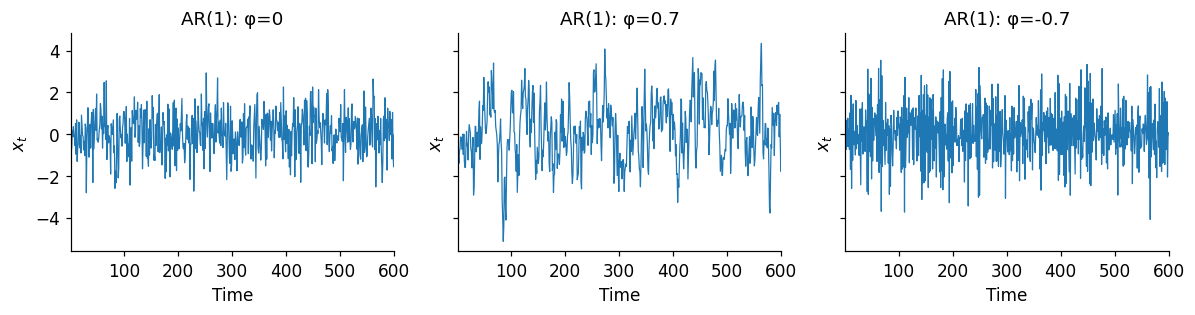

In [2]:
phis = [0., .7, -.7]
# Resetting the generator gives each coefficient the same Gaussian shock sequence.
persistence_paths = {phi:simulate_ar1(phi, 1, 600, rng=np.random.default_rng(510)) for phi in phis}
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True, sharey=True)
for ax, phi in zip(axes, phis):
    ax.plot(np.arange(1, illustration_window+1), persistence_paths[phi][:illustration_window], linewidth=.8)
    ax.set(title=f"AR(1): φ={phi:g}", xlabel="Time", ylabel="$x_t$", xlim=(1,illustration_window))
fig.tight_layout()
plt.show()


Positive persistence produces runs of similar signed values, while negative persistence produces alternating dependence. Population moments are fixed by the model; sample moments fluctuate across histories.


#### Higher-Order Dependence: AR(2)

For illustration, I use
$$X_t=-1.2X_{t-1}-0.3X_{t-2}+\varepsilon_t,\qquad\varepsilon_t\sim GWN(0,4).$$
I simulate 600 observations using seed 808, with 1000 burn-in observations to approximate stationary initialization. The roots lie outside the unit circle. 
For illustration, I compare two additional stationary specifications, $(\phi_1,\phi_2)=(.6,.2)$ and $(.2,.6)$, with the same innovations, variance four and seed 1808. The histories show how changing the lag weights affects the realized series. Overall persistence depends on the AR roots, not simply on the larger coefficient.

AR roots: [-2.81649658 -1.18350342]


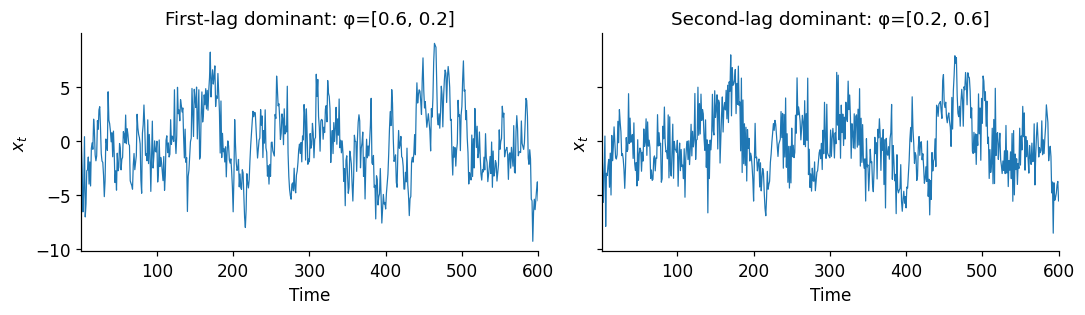

In [3]:
ar2_process = ArmaProcess(np.array([1., 1.2, .3]), np.array([1.]))
ar2_values = ar2_process.generate_sample(600, scale=2, burnin=1000,
                                        distrvs=np.random.default_rng(808).standard_normal)
assert is_stationary_ar([-1.2, -.3])
print("AR roots:", ar_roots([-1.2, -.3]))

ar2_comparisons = [("First-lag dominant", [.6,.2]), ("Second-lag dominant", [.2,.6])]
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True, sharey=True)
for column, (label, coefficients) in enumerate(ar2_comparisons):
    assert is_stationary_ar(coefficients)
    process = ArmaProcess(np.r_[1., -np.asarray(coefficients)], [1.])
    values = process.generate_sample(600, scale=2, burnin=1000,
                                    distrvs=np.random.default_rng(1808).standard_normal)
    axes[column].plot(np.arange(1,illustration_window+1), values[:illustration_window], linewidth=.8)
    axes[column].set(title=f"{label}: φ={coefficients}", xlabel="Time", ylabel="$x_t$", xlim=(1,illustration_window))
fig.tight_layout()
plt.show()


Both specifications are stationary. With the same innovations, the different histories reflect the change in lag weights. The ACF and PACF below provide a clearer basis for identifying dependence than the histories alone.

## 2. Moving-Average Models: MA(q)

A moving-average model describes the current value through the current innovation and a finite number of previous innovations. Whereas AR models use lagged observations, MA models describe the contributions of recent shocks directly. This is a model of dependence, rather than a rolling average used to smooth data.

### MA(1)

Begin with a moving average involving one lagged innovation, then examine its moments and short-lived dependence.

#### Model

**Definition: MA(1).** A moving-average process of order one combines current and previous white-noise innovations:
$$X_t=\mu+\varepsilon_t+\theta\varepsilon_{t-1},\qquad
\varepsilon_t\sim WN(0,\sigma^2).$$

#### Population Moments

Using zero cross-time covariance of the innovations,
$$E[X_t]=\mu,\qquad \gamma_0=\sigma^2(1+\theta^2),\qquad
\gamma_1=\theta\sigma^2,$$
$$\rho_1=\frac{\theta}{1+\theta^2},\qquad \gamma_j=\rho_j=0\quad(j>1).$$
Only the shared innovation contributes to lag-one covariance; beyond that lag, the innovation sets do not overlap.

#### Stationarity Conditions

MA(1) is covariance-stationary for every finite $\theta$ under the white-noise assumptions. **Invertibility** is a separate condition, $|\theta|<1$, allowing recovery of shocks from present and past observations.

### General MA(q)

A finite moving average extends this construction to several lagged innovations.

#### Model

**Definition: MA(q).** A moving-average process of order q combines current and q previous white-noise innovations:
$$X_t=\mu+\varepsilon_t+\theta_1\varepsilon_{t-1}+\cdots+\theta_q\varepsilon_{t-q},
\qquad\varepsilon_t\sim WN(0,\sigma^2).$$

#### Population Moments

Writing $\theta_0=1$,
$$E[X_t]=\mu,\qquad\gamma_0=\sigma^2\sum_{k=0}^q\theta_k^2,$$
$$\gamma_j=\sigma^2\sum_{k=0}^{q-j}\theta_k\theta_{k+j}\quad(1\le j\le q),\qquad
\gamma_j=0\quad(j>q).$$
The autocorrelation is $\rho_j=\gamma_j/\gamma_0$, so dependence ends after lag q.

#### Stationarity Conditions

Every finite MA(q) is covariance-stationary under the white-noise assumptions. **Invertibility** means that innovations can be recovered by a convergent causal linear filter of the observations. It requires the roots of $1+\theta_1z+\cdots+\theta_qz^q=0$ to lie outside the unit circle.

### Illustration: Innovation Dependence

For illustration, I simulate 600 observations with $\theta=.7$, innovation variance one and seed 909. This introductory coefficient makes positive lag-one dependence easy to see. The next example uses the two-lag moving-average specification.
For illustration, I compare θ=0,.7,−.7 using the same innovations and 600 displayed observations. The question is how the sign of the lagged shock changes adjacent movements. The effect ends after one lag, unlike the infinite propagation in a stationary AR(1). A path alone does not identify the model order.

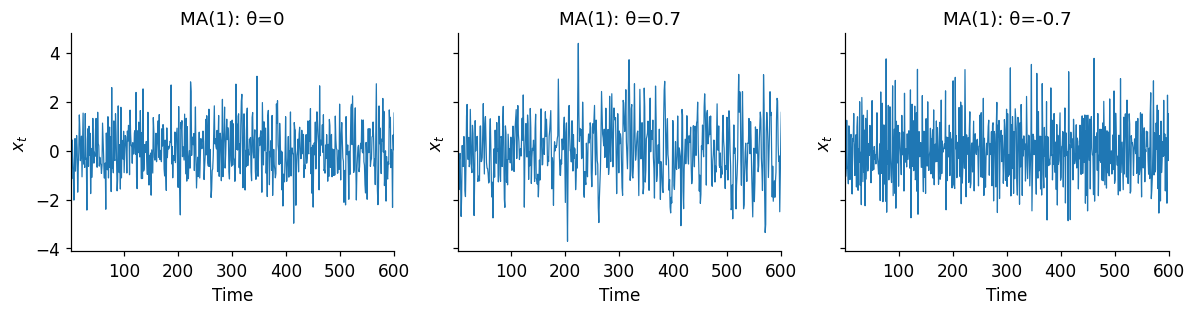

In [4]:
ma1_values = simulate_ma([.7], 1, 600, rng=909)
ma1_process = ArmaProcess([1.], [1., .7])


ma1_coefficients = [0., .7, -.7]
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True, sharey=True)
for ax, coefficient in zip(axes, ma1_coefficients):
    values = simulate_ma([coefficient], 1, 600, rng=909)
    ax.plot(np.arange(1,illustration_window+1), values[:illustration_window], linewidth=.8)
    ax.set(title=f"MA(1): θ={coefficient:g}", xlabel="Time", ylabel="$x_t$", xlim=(1,illustration_window))
fig.tight_layout()
plt.show()


Positive θ reinforces adjacent shocks; negative θ reverses their lag-one contribution. This is finite shock dependence, not persistent feedback from past observations.

#### Higher-Order Dependence: MA(2)

For illustration, I use
$$X_t=\varepsilon_t-.8\varepsilon_{t-1}+.9\varepsilon_{t-2},\qquad\varepsilon_t\sim GWN(0,1).$$
I simulate 600 observations with seed 910. The function draws the two pre-sample innovations, so every observation follows the stationary finite-MA law. For illustration, I compare additional invertible specifications θ=(.6,.2) and (.2,.6), sharing innovations with seed 1910. The histories show how changing the weights on the two previous innovations affects the realized series.

MA roots: [0.44444444-0.95581392j 0.44444444+0.95581392j]


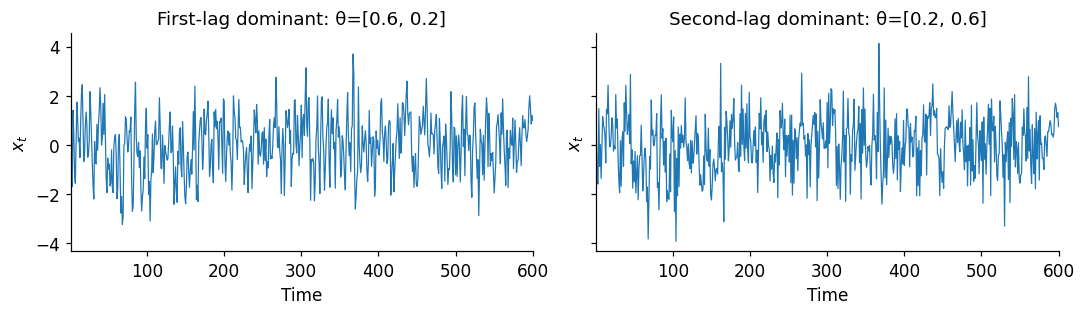

In [5]:
ma2_values = simulate_ma([-.8, .9], 1, 600, rng=910)
ma2_process = ArmaProcess([1.], [1., -.8, .9])
assert is_invertible_ma([-.8, .9])
print("MA roots:", ma_roots([-.8, .9]))

ma2_comparisons = [("First-lag dominant", [.6,.2]), ("Second-lag dominant", [.2,.6])]
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True, sharey=True)
for column, (label, coefficients) in enumerate(ma2_comparisons):
    assert is_invertible_ma(coefficients)
    values = simulate_ma(coefficients, 1, 600, rng=1910)
    axes[column].plot(np.arange(1,illustration_window+1), values[:illustration_window], linewidth=.8)
    axes[column].set(title=f"{label}: θ={coefficients}", xlabel="Time", ylabel="$x_t$", xlim=(1,illustration_window))
fig.tight_layout()
plt.show()


Changing the dominant lag changes how past innovations enter the observations. Both models still depend on only the current innovation and the two preceding innovations.

## 3. Autoregressive Integrated Moving-Average Models: ARIMA(p,i,q)

ARMA combines dependence on previous observations with dependence on previous innovations. I first define this model for a stationary process, then introduce ARIMA for cases where differencing yields a stationary series. The distinction is between modeling levels and modeling their changes.

### ARMA(p,q)

Combining autoregressive and moving-average terms allows a parsimonious description of more varied temporal dependence.

#### Model

**Definition: ARMA(p,q).** An autoregressive moving-average process combines p observation lags with q innovation lags:
$$X_t-\mu=\sum_{i=1}^p\phi_i(X_{t-i}-\mu)+\varepsilon_t+
\sum_{j=1}^q\theta_j\varepsilon_{t-j},\qquad\varepsilon_t\sim WN(0,\sigma^2).$$
#### Population Moments

For the causal stationary case, $E[X_t]=\mu$. With the innovation weights $\psi_k$ from the Wold representation in Notebook 07,
$$\gamma_j=\sigma^2\sum_{k=0}^{\infty}\psi_k\psi_{k+j}\quad(j\ge0),\qquad
\rho_j=\frac{\gamma_j}{\gamma_0}.$$
At lag zero this gives the variance. Both AR and MA coefficients determine the weights, so the population ACF generally decays rather than having a finite cutoff.

#### Stationarity Conditions

AR roots outside the unit circle give causal stationarity. **Invertibility** separately requires MA roots outside the unit circle. Common AR and MA factors can be canceled to obtain a lower-order representation.

### ARIMA(p,i,q)

When a series has a stochastic trend, a stationary model may be appropriate for its changes rather than its level. ARIMA incorporates this transformation: i counts the differences, while p and q describe the AR and MA components of the resulting series. Differencing is a modeling choice that needs justification, rather than a step applied automatically to every series.

#### Model

**Definition: ARIMA(p,i,q).** A process $Y_t$ follows an ARIMA model when taking i successive differences gives a stationary ARMA(p,q) process $X_t$. The first difference is $Y_t-Y_{t-1}$; a second difference subtracts consecutive first differences, and higher orders repeat this step. The differenced model is
$$X_t-\mu=\sum_{j=1}^p\phi_j(X_{t-j}-\mu)+\varepsilon_t+
\sum_{k=1}^q\theta_k\varepsilon_{t-k},\qquad\varepsilon_t\sim WN(0,\sigma^2).$$
For i=0, $X_t=Y_t$; for i=1, $X_t=Y_t-Y_{t-1}$. The orders count AR lags, differences and MA lags.

#### Population Moments

The stationary moments above apply to $X_t$, with $\mu=E[X_t]$, not generally to the level $Y_t$. For i=1, a nonzero mean of the increments gives drift in the level. The level's mean or variance can change with time even though its differences have stable moments.

#### Stationarity Conditions

The differenced process must satisfy the ARMA stationarity conditions; invertibility concerns its MA component. For i>0 the original level is generally non-stationary. A deterministic trend or changing variance does not automatically justify differencing.

The zero-drift random walk is ARIMA(0,1,0), since $Y_t-Y_{t-1}=\varepsilon_t$. Notebook 07 introduced this stochastic trend; differencing now provides its modeling framework.

For the identification illustration below, I simulate 600 observations from
$$X_t=X_{t-1}-.75X_{t-2}+\varepsilon_t-.8\varepsilon_{t-1}+.9\varepsilon_{t-2},\qquad
\varepsilon_t\sim GWN(0,1),$$
using seed 1010 and 1000 burn-in observations. Both AR and MA roots lie outside the unit circle. Neither ACF nor PACF has the finite cutoff of a pure AR or MA model.
The history illustrates the combined shock-propagation mechanism. Its appearance alone cannot distinguish the AR and MA components.

In [6]:
arma_process = ArmaProcess([1., -1., .75], [1., -.8, .9])
arma_values = arma_process.generate_sample(600, burnin=1000,
                                          distrvs=np.random.default_rng(1010).standard_normal)
assert arma_process.isstationary and arma_process.isinvertible


### Illustration: Before and After Differencing

For illustration, I use $\phi=.7$, $\theta=.4$, innovation standard deviation two and 600 increments, with seed 123:
$$\Delta Y_t=.7\Delta Y_{t-1}+\varepsilon_t+.4\varepsilon_{t-1}.$$
I initialize $Y_0=0$ and accumulate a simulated stationary ARMA(1,1) increment process after 1000 burn-in observations. The level path and its first difference show what integration changes. The differenced model has no intercept or trend, matching the zero-drift construction. Identification and estimation use only the observations preceding the reserved continuation.

Differencing need not fix every form of non-stationarity. It is appropriate here because the construction has a unit root. A deterministic trend or changing variance calls for a different assessment.
The two panels compare the integrated level with its first difference. For the later forecast example, I reserve the final 24 levels as out-of-sample observations and fit using only the preceding levels. The generating specification is fixed in advance.

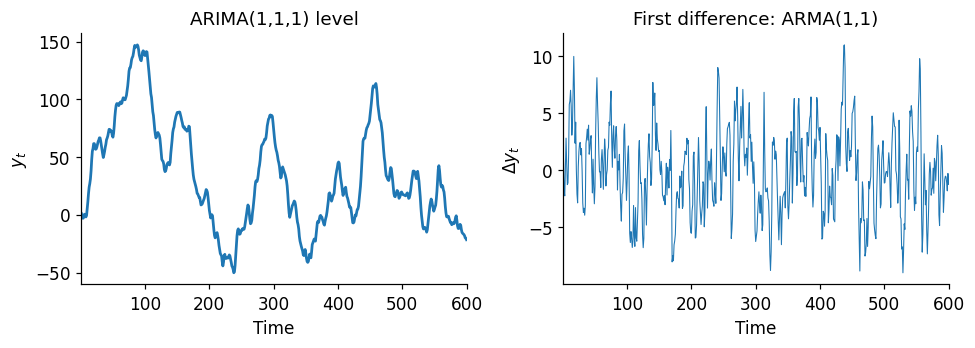

In [7]:
increment_process = ArmaProcess([1., -.7], [1., .4])
arima_increments = increment_process.generate_sample(600, scale=2, burnin=1000,
                                                     distrvs=np.random.default_rng(123).standard_normal)
arima_levels = np.r_[0., np.cumsum(arima_increments)]
np.testing.assert_allclose(difference(arima_levels), arima_increments, atol=1e-12)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
axes[0].plot(np.arange(1,illustration_window+1), arima_levels[1:illustration_window+1]); axes[0].set(title="ARIMA(1,1,1) level", xlabel="Time", ylabel="$y_t$")
axes[1].plot(np.arange(1,illustration_window+1), arima_increments[:illustration_window], linewidth=.7); axes[1].set(title="First difference: ARMA(1,1)", xlabel="Time", ylabel="$\Delta y_t$")
for ax in axes:
    ax.set_xlim(1,illustration_window)
fig.tight_layout()
plt.show()
arima_horizon = forecast_horizon
arima_train = arima_levels[:-arima_horizon]
arima_test = arima_levels[-arima_horizon:]

# All forecast examples reserve 24 subsequent observations before estimation.
ar_train, ar_test = persistence_paths[.7][:-forecast_horizon], persistence_paths[.7][-forecast_horizon:]
ma_train, ma_test = ma2_values[:-forecast_horizon], ma2_values[-forecast_horizon:]
arma_train, arma_test = arma_values[:-forecast_horizon], arma_values[-forecast_horizon:]


The integrated level accumulates changes, while its first difference fluctuates around a stable mean. The shared time window makes the transformation visible without implying that every non-stationary series should be differenced.

## 4. Estimation, Diagnostics and Evaluation

Estimate candidate models, identify plausible orders and check residual dependence before comparing specifications.

### Maximum Likelihood Estimation

Notebook 03 introduced likelihood as a function of unknown parameters for the observed sample. For time-series data, conditional densities account for the observed past:
$$\ell_c(\theta)=\sum_t\log f_\theta(x_t\mid\mathcal F_{t-1}),\qquad
\hat\theta=\underset{\theta\in\Theta}{\arg\max}\;\ell_c(\theta).$$
The sum runs over estimation observations after the chosen initialization. Log-likelihood turns a product of conditional densities into a sum without changing its maximizer.

White noise specifies zero mean, constant finite variance and zero correlation across time. It does not by itself specify independence or a density, so it is sufficient for many population-moment results but not a complete likelihood assumption. The worked AR(p), MA(q) and ARMA models use IID Gaussian innovations and constant innovation variance. For ARIMA(p,i,q), these assumptions concern the stationary differenced model, rather than a stationary original level.

Conditional Gaussian AR likelihood, given the initial observations, gives OLS coefficient estimates when the optimum lies in the admissible parameter space. Exact likelihood also treats initialization, so this equivalence does not generally apply to it or to MA/ARMA estimation. The worked fits use Gaussian exact state-space likelihood and enforce causal stationarity and invertibility for the ARMA components.

I fit the simulated AR(1), MA(2), ARMA(2,2) and ARIMA(1,1,1), reserving the final 24 observations before estimation. The compact AR(1) table reports estimates and approximate likelihood-based standard errors. I fit the other models for diagnostics and forecasting without repeating their parameter tables.

In [8]:
limited_fit = ARIMA(ar_train,order=(1,0,0),trend="c").fit()
assert limited_fit.mle_retvals.get("converged",True)
display(pd.DataFrame({"estimate":limited_fit.params,"standard error":limited_fit.bse},index=limited_fit.param_names).round(4))

ma_fit = ARIMA(ma_train, order=(0,0,2), trend="c").fit()
assert ma_fit.mle_retvals.get("converged", True)

arma_fit = ARIMA(arma_train, order=(2,0,2), trend="c").fit()
assert arma_fit.mle_retvals.get("converged", True)
arima_fit = ARIMA(arima_train, order=(1,1,1), trend="n").fit()
assert arima_fit.mle_retvals.get("converged", True)


,estimate,standard error
const,0.1822,0.1512
ar.L1,0.7305,0.0286
sigma2,0.9490,0.0558


### Model Identification

Identification proposes model orders from the observed dependence pattern. I use ACF/PACF first, then explain automatic ARIMA identification. Both provide candidates rather than proof of the underlying model.

#### ACF and PACF

The ACF measures correlation between observations separated by a lag. **Definition: partial autocorrelation.** The PACF at lag j is the correlation between $X_t$ and $X_{t-j}$ after linearly removing the intervening lags from both.

| Population process | ACF | PACF |
|---|---|---|
| AR(p) | Decays | Cuts off after p |
| MA(q) | Cuts off after q | Decays |
| ARMA(p,q) | Decays | Decays |

These patterns apply to nondegenerate minimal representations. For ARIMA, examine the stationary differenced series rather than applying these rules to an integrated level.

#### Automatic ARIMA Identification

An automatic procedure combines a differencing decision with a search over AR and MA orders. The course uses `auto.arima` with ADF-based differencing, BIC, non-seasonal models and an exhaustive search up to order five. Python's `pmdarima.auto_arima` provides analogous controls. The tests, search bounds and deterministic terms must be specified. Automatic identification proposes a candidate, which still needs residual diagnostics. The examples below retain their stated model orders rather than running another search.

#### Example: Identifying AR, MA and ARMA Dependence

For illustration, I compare the existing AR(2), MA(2) and ARMA(2,2) examples, excluding the reserved continuation where applicable. The figure asks whether their finite-sample ACF/PACF recover the population cutoff or decay patterns. Known population curves explain the simulation and would not be available for real observations.

Dashed lines show the approximate pointwise 95% white-noise reference bounds $\pm1.96/\sqrt{n}$, using the number of observations in each plotted sample. They are centered on zero, not on the estimated correlations or population curve. Exceeding a bound flags possible dependence; these are not simultaneous bounds, and fitted-residual and squared-series interpretations remain approximate and require suitable moment assumptions.

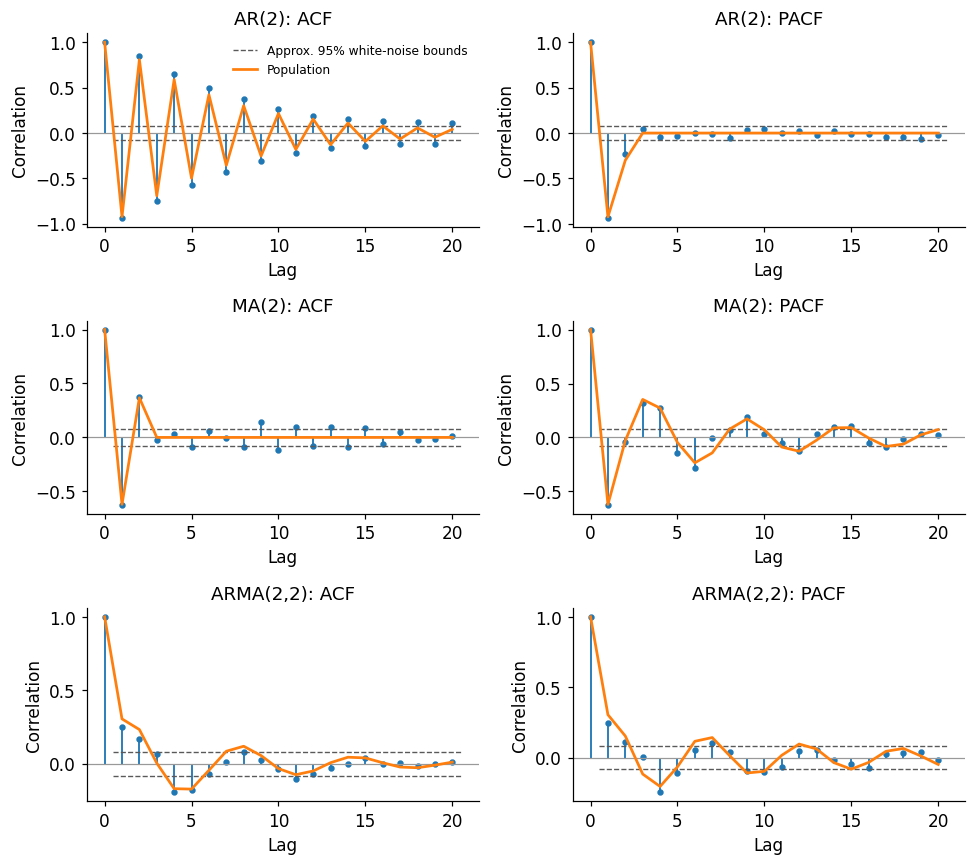

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(9, 8))
for row, values, process, label in [(0, ar2_values, ar2_process, "AR(2)"),
                                     (1, ma_train, ma2_process, "MA(2)"),
                                     (2, arma_train, arma_process, "ARMA(2,2)")]:
    stem_dependence(axes[row,0], acf(values, 20), f"{label}: ACF", len(values))
    axes[row,0].plot(np.arange(21), process.acf(21), color="C1", label="Population")
    stem_dependence(axes[row,1], pacf(values, nlags=20, method="ywm"), f"{label}: PACF", len(values))
    axes[row,1].plot(np.arange(21), process.pacf(21), color="C1", label="Population")
axes[0,0].legend(fontsize=8)
fig.tight_layout()
plt.show()


The population cutoff patterns are clearer than their finite-sample estimates. These plots suggest candidate orders; they do not replace likelihood comparison or residual assessment.

### Residual Diagnostics

After fitting, I examine what the model leaves unexplained. Innovations are population quantities, while residuals are their estimated counterparts. An adequate conditional-mean model should leave no systematic linear dependence in its prediction errors. Residual diagnostics assess this rather than whether the original series is uncorrelated.

#### Ljung–Box Test

The null is that residual autocorrelations through lag h are zero. The statistic is
$$Q_{LB}=T(T+2)\sum_{j=1}^{h}\frac{\hat\rho_j^2}{T-j}.$$
After fitting ARMA(p,q), its conventional approximate reference is $\chi^2_{h-p-q}$, with $h>p+q$. A small p-value indicates remaining serial correlation. Non-rejection does not establish independence or constant conditional variance. Here T counts retained residuals, and the test uses denominator-T autocovariances.

#### ACF of Standardized Residuals

Standardized residuals divide each one-step prediction error by its fitted prediction standard deviation:
$$z_t=\frac{\hat\varepsilon_t}{\hat s_t}.$$
For a correctly specified Gaussian model, their population counterpart has zero mean, unit variance and no serial correlation. Their sample ACF reveals which lags contribute remaining dependence. Standardization changes units and accounts for initialization uncertainty, rather than removing serial correlation.

#### Example: Checking the Fitted Models

For illustration, I report Ljung–Box checks on the residuals and plot the ACF of standardized residuals for the four fitted examples. I exclude the initial affected observations. The question is whether linear dependence remains after modeling the conditional mean.

,statistic,p_value,df,lags,nobs
Model,,,,,
AR(1),11.9613,0.8873,19,20,575
MA(2),21.4542,0.2571,18,20,574
"ARMA(2,2)",9.7584,0.8789,16,20,574
"ARIMA(1,1,1)",11.3409,0.8793,18,20,576


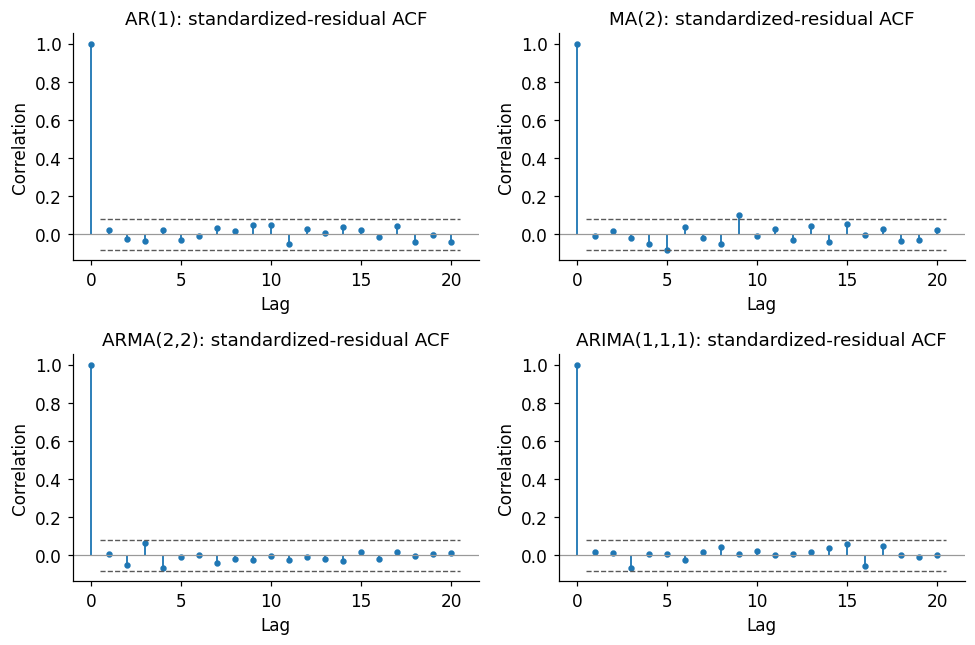

In [10]:
residual_examples = [
    ("AR(1)", np.asarray(limited_fit.resid)[1:], 1),
    ("MA(2)", np.asarray(ma_fit.resid)[2:], 2),
    ("ARMA(2,2)", np.asarray(arma_fit.resid)[2:], 4),
    ("ARIMA(1,1,1)", np.asarray(arima_fit.resid)[1:], 2),
]
display(pd.DataFrame([{"Model":name, **ljung_box(values, 20, model_df=df)}
                      for name, values, df in residual_examples]).set_index("Model").round(4))
standardized_examples = [
    ("AR(1)", limited_fit, 1), ("MA(2)", ma_fit, 2),
    ("ARMA(2,2)", arma_fit, 2), ("ARIMA(1,1,1)", arima_fit, 1),
]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, (name, fit, initial) in zip(axes.ravel(), standardized_examples):
    standardized = np.asarray(fit.filter_results.standardized_forecasts_error)[0, initial:]
    assert np.all(np.isfinite(standardized))
    stem_dependence(ax, acf(standardized, 20, adjusted=False),
                    f"{name}: standardized-residual ACF", len(standardized))
fig.tight_layout()
plt.show()


Remaining residual spikes describe this estimation sample. The Ljung–Box screen checks their collective significance, while variance dependence requires a separate squared-residual analysis.

### Model Selection: AIC and BIC

As in Notebook 03, these criteria balance maximized likelihood against parameter count:
$$AIC=-2\ell(\hat\theta)+2m,\qquad BIC=-2\ell(\hat\theta)+m\log n.$$
Here m counts all estimated parameters, including the innovation variance, and n is the number of estimation observations. Lower values favor a candidate fitted to the same data with a comparable likelihood and transformation. AIC and BIC can disagree. Neither guarantees adequate residuals or more accurate out-of-sample forecasts.

#### Example: Comparing AR(1), MA(1) and ARMA(1,1)

For illustration, I simulate 600 observations from
$$X_t=.6X_{t-1}+\varepsilon_t+.4\varepsilon_{t-1},\qquad\varepsilon_t\sim GWN(0,1),$$
using seed 18081 and 1000 burn-in observations. The model is stationary and invertible. I fit AR(1), MA(1) and ARMA(1,1) to exactly the same observations using Gaussian state-space likelihood and an estimated constant. The question is whether the additional ARMA parameter improves likelihood enough to offset its information-criterion penalty.

In [11]:
comparison_process = ArmaProcess([1., -.6], [1., .4])
assert comparison_process.isstationary and comparison_process.isinvertible
comparison_sample = comparison_process.generate_sample(
    600, burnin=1000, distrvs=np.random.default_rng(18081).standard_normal)
criteria_rows = []
for label, order in [("AR(1)", (1,0,0)), ("MA(1)", (0,0,1)), ("ARMA(1,1)", (1,0,1))]:
    fit = ARIMA(comparison_sample, order=order, trend="c").fit()
    assert fit.mle_retvals.get("converged", True)
    parameter_count = len(fit.params)
    np.testing.assert_allclose(fit.aic, -2*fit.llf + 2*parameter_count)
    np.testing.assert_allclose(fit.bic, -2*fit.llf + parameter_count*np.log(len(comparison_sample)))
    criteria_rows.append({"Model":label, "Parameters":parameter_count,
                          "Log-likelihood":fit.llf, "AIC":fit.aic, "BIC":fit.bic})
criteria_table = pd.DataFrame(criteria_rows).set_index("Model")
display(criteria_table.round(3))
print("Lowest AIC:", criteria_table["AIC"].idxmin(),
      "| Lowest BIC:", criteria_table["BIC"].idxmin())

,Parameters,Log-likelihood,AIC,BIC
Model,,,,
AR(1),3,-858.635,1723.270,1736.461
MA(1),3,-909.636,1825.272,1838.463
"ARMA(1,1)",4,-845.072,1698.144,1715.732


Lowest AIC: ARMA(1,1) | Lowest BIC: ARMA(1,1)


The parameter count includes the constant and innovation variance. ARMA(1,1) contains both simpler models as special cases, so its maximized likelihood can improve, but its penalty is larger. AIC and BIC balance that improvement differently. The generating model need not be selected in every finite sample, and the preferred candidate still requires residual diagnostics. This in-sample comparison does not establish out-of-sample forecasting superiority.

## 5. Forecasting

Use the fitted temporal model and information available at the forecast origin to predict future observations and quantify uncertainty.

### Definition

The information set $\mathcal F_n$ contains observations available at forecast origin n. Under squared-error loss, the minimum-MSE forecast is the conditional expectation:
$$\hat X_{n+h|n}=E[X_{n+h}\mid\mathcal F_n].$$
The formulas below substitute estimated parameters. Independent zero-mean innovations justify setting future innovations to zero in the forecast. White-noise covariance alone is insufficient for this conditional-expectation interpretation.

### AR(p) Forecasts

For AR(1),
$$\hat x_{n+h}=\hat\mu+\hat\phi^h(x_n-\hat\mu).$$
For AR(p), iterate
$$\hat x_{n+h}=\hat\mu+\sum_{j=1}^p\hat\phi_j(\hat x_{n+h-j}-\hat\mu),$$
using observed values when $h-j\le0$. For a stationary model, the forecast approaches the mean.

### MA(q) Forecasts

For an invertible MA(q), use the estimated past innovations:
$$\hat x_{n+h}=\hat\mu+\sum_{j=h}^q\hat\theta_j\hat\varepsilon_{n+h-j}\quad(1\le h\le q).$$
For $h>q$, the forecast is $\hat\mu$, since no observed innovation remains in the future observation's MA terms.

### ARIMA(p,i,q) Forecasts

First forecast the stationary differences using the ARMA recursion:
$$\hat x_{n+h}=\hat\mu+\sum_{j=1}^p\hat\phi_j(\hat x_{n+h-j}-\hat\mu)
+\sum_{j=h}^q\hat\theta_j\hat\varepsilon_{n+h-j}.$$
The MA sum is zero when $h>q$. For i=1, recover level forecasts by accumulation:
$$\hat y_{n+h}=y_n+\sum_{j=1}^h\hat x_{n+j}.$$
Higher integration orders require repeated accumulation. Level uncertainty need not approach a stationary variance bound.

### Evaluation

Following the course, define $e_{T+j}=x_{T+j}-\hat x_{T+j}$. For k forecasts,
$$ME=\frac1k\sum_{j=1}^k e_{T+j},\qquad
RMSE=\sqrt{\frac1k\sum_{j=1}^k e_{T+j}^2},\qquad
MAE=\frac1k\sum_{j=1}^k|e_{T+j}|.$$
ME summarizes signed forecast error, RMSE gives greater weight to large errors, and MAE summarizes absolute error. These have observation units. Forecast error concerns future observations, unlike estimator MSE in Notebook 03. Percentage errors can be unstable for returns near zero, so I omit them here.

A prediction interval concerns a future observation. For Gaussian models it uses the forecast mean and forecast standard deviation. Fitted-model intervals condition on estimated parameters and generally omit their estimation uncertainty.

### Example: ARIMA(1,1,1)

For illustration, I fit the stated ARIMA(1,1,1) to the estimation observations and forecast the final 24 reserved levels. The line shows the conditional-mean forecast, the band its 95% prediction interval, and the dots the out-of-sample realization. The question is how closely this one continuation follows the forecast, accounting for uncertainty from future innovations.

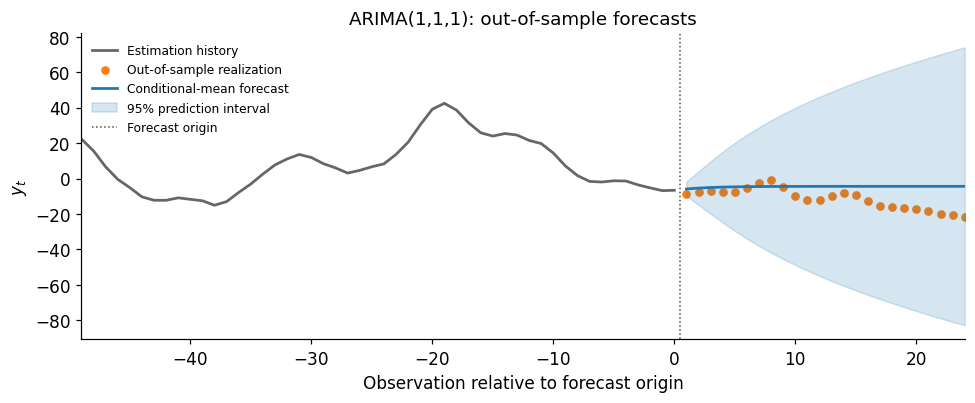

,ME,RMSE,MAE
"ARIMA(1,1,1)",-6.707,8.8703,7.1949


In [12]:
arima_prediction = forecast_panel(arima_fit, arima_train, arima_test,
                                  "ARIMA(1,1,1): out-of-sample forecasts", ylabel="$y_t$")
arima_forecast = np.asarray(arima_prediction.predicted_mean)
errors = arima_test - arima_forecast
display(pd.DataFrame([{"ME":np.mean(errors), "RMSE":forecast_rmse(arima_test, arima_forecast),
                      "MAE":forecast_mae(arima_test, arima_forecast)}],
                     index=["ARIMA(1,1,1)"]).round(4))

The out-of-sample dots need not follow the conditional mean. The error measures describe this finite continuation, rather than establishing general forecasting performance.

A conditional-mean model can leave little residual serial correlation while still leaving dependence in squared residuals. Notebook 09 studies that remaining magnitude dependence through conditional variance.